In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Illustration 9.4-4 &mdash; two routes to a species fugacity (CO&#8322; / methane)

This notebook reproduces **Illustration 9.4-4**: the same quantity, computed two ways
that disagree, for an equimolar carbon dioxide / methane mixture at 500 K and 500 bar.

The **Lewis&ndash;Randall rule** treats each species in the mixture as if it were the pure
fluid at the mixture's temperature and pressure,

$$\bar f_i(T,P,\underline y) = y_i f_i(T,P) = y_i \left(\frac{f}{P}\right)_i P$$

so it needs only a pure-component fugacity coefficient &mdash; read off the
corresponding-states chart, Fig. 7.4-1. The **Peng&ndash;Robinson** route uses Eq. 9.4-9
and accounts for the species interacting with each other.

At 500 bar the difference is not small, and the comparison is the point of the
illustration.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from thermo.charts import use_book_style
use_book_style()
R = constants.R

## (a) The Lewis–Randall rule

Illustration 9.4-4 reads the pure-fluid fugacity coefficients off Fig. 7.4-1 at the
reduced conditions, and notes that the methane value had to be taken from Hougen, Watson
and Ragatz because the chart is unreadable there. Both are reproduced as *chart reads*,
to the precision a chart supports.

In [3]:
from thermo import PengRobinson
T, P = 500.0, 500e5
y = np.array([0.5, 0.5])                      # CO2, CH4

chart = {"carbon dioxide": 0.77, "methane": 1.01}     # f/P from Fig. 7.4-1 and HWR
for name, phi in chart.items():
    pure = PengRobinson.from_database(name)
    Tr, Pr = T / pure.Tc, P / pure.Pc
    print(f"  {name:15s} Tr = {Tr:.3f}  Pr = {Pr:.2f}   f/P ~ {phi}")

f_LR = np.array([0.5 * chart["carbon dioxide"] * 500, 0.5 * chart["methane"] * 500])
print(f"\nLewis-Randall:  f_CO2 = {f_LR[0]:.1f} bar   f_CH4 = {f_LR[1]:.1f} bar")
print( "book          :  f_CO2 = 192.5 bar   f_CH4 = 252.5 bar")

  carbon dioxide  Tr = 1.644  Pr = 6.78   f/P ~ 0.77
  methane         Tr = 2.626  Pr = 10.87   f/P ~ 1.01

Lewis-Randall:  f_CO2 = 192.5 bar   f_CH4 = 252.5 bar
book          :  f_CO2 = 192.5 bar   f_CH4 = 252.5 bar


## (b) Peng–Robinson, with and without the binary interaction parameter

In [4]:
from thermo import PRMixture
from thermo.data import pr_kij_matrix

kij, _ = pr_kij_matrix(["carbon dioxide", "methane"])
print(f"Table 9.4-1: k_ij(CO2, CH4) = {kij[0,1]}      (the illustration uses 0.09)")

rows = []
for k in (0.0, float(kij[0, 1])):
    mk = PRMixture.from_database(["carbon dioxide", "methane"], kij=[[0, k], [k, 0]])
    f = mk.fugacity(y, T, P, "vapor") / 1e5
    rows.append((k, f[0], f[1]))
    print(f"  k_ij = {k:.2f}   f_CO2 = {f[0]:7.2f} bar   f_CH4 = {f[1]:7.2f} bar")
print("\nbook:  k_ij = 0.00  ->  208.71, 264.72")
print(  "       k_ij = 0.09  ->  212.81, 269.35")

Table 9.4-1: k_ij(CO2, CH4) = 0.09      (the illustration uses 0.09)
  k_ij = 0.00   f_CO2 =  210.39 bar   f_CH4 =  265.31 bar
  k_ij = 0.09   f_CO2 =  214.46 bar   f_CH4 =  269.88 bar

book:  k_ij = 0.00  ->  208.71, 264.72
       k_ij = 0.09  ->  212.81, 269.35


## The comparison

Lewis-Randall underestimates the CO2 fugacity by 10% and the CH4 fugacity by 6%.
k_ij moves the PR answer by 1.9% (CO2) and 1.7% (CH4).


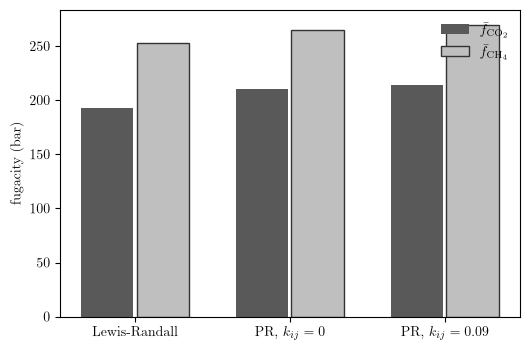

In [5]:
labels = ["Lewis-Randall", "PR, $k_{ij}=0$", "PR, $k_{ij}=0.09$"]
fCO2 = [f_LR[0], rows[0][1], rows[1][1]]
fCH4 = [f_LR[1], rows[0][2], rows[1][2]]
i = np.arange(3)
fig, ax = plt.subplots(figsize=(5.4, 3.6))
ax.bar(i - 0.18, fCO2, 0.34, color="0.35", label=r"$\bar f_{\mathrm{CO_2}}$")
ax.bar(i + 0.18, fCH4, 0.34, color="0.75", edgecolor="0.2", label=r"$\bar f_{\mathrm{CH_4}}$")
ax.set_xticks(i); ax.set_xticklabels(labels); ax.set_ylabel("fugacity (bar)")
ax.legend(frameon=False); fig.tight_layout()

print(f"Lewis-Randall underestimates the CO2 fugacity by "
      f"{100*(rows[1][1]-f_LR[0])/rows[1][1]:.0f}% and the CH4 fugacity by "
      f"{100*(rows[1][2]-f_LR[1])/rows[1][2]:.0f}%.")
print(f"k_ij moves the PR answer by {100*(rows[1][1]-rows[0][1])/rows[0][1]:.1f}% (CO2) "
      f"and {100*(rows[1][2]-rows[0][2])/rows[0][2]:.1f}% (CH4).")

**Both effects are real and they are different sizes.** The Lewis–Randall rule is
wrong here by about 10%, because at 500 bar a CO₂ molecule's neighbors are as often
methane as CO₂ and the rule ignores that entirely. The binary interaction parameter is a
2% correction on top of the equation of state — small next to the Lewis–Randall error,
but the same size as the difference between two equations of state, which is why
Illustration 9.4-4 calls the $k_{ij}=0.09$ numbers *"the most accurate."*

**The Lewis–Randall numbers are chart reads and print at chart precision.** $f/P
\sim 0.77$ is two significant figures; carrying the result to 192.5 bar states more
precision than the input has. The book does the same thing, and the comparison is
unaffected — but a notebook that prints `192.50000` is lying about its inputs.

**Your turn.** Sweep the pressure from 1 to 500 bar and plot the ratio of the
Lewis–Randall fugacity to the Peng–Robinson one for CO₂. At what pressure does the
Lewis–Randall rule stop being good to 1%?